In [6]:
!pip install -U langgraph
!pip install -U langchain
!pip install -U langchain-core
!pip install -U langchain-community

!pip install -U langchain-ollama

!pip install -U langchain-text-splitters

!pip install -U langchain-huggingface

!pip install -U langchain-chroma

!pip install -U faiss-cpu

!pip install -U pypdf

!pip install -U pandas

!pip install -U sqlalchemy

!pip install -U sentence-transformers

  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.5
    Uninstalling langgraph-1.2.5:
      Successfully uninstalled langgraph-1.2.5
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.9
    Uninstalling langchain-1.3.9:
      Successfully uninstalled langchain-1.3.9
   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ---------------------------------------- 557.4/557.4 kB 7.9 MB/s  0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.7
    Uninstalling langchain-core-1.4.7:
      Successfully uninstalled langchain-core-1.4.7
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.8 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------- 9.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.3 which is incompatible.


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 17.9 MB/s  0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.43
    Uninstalling SQLAlchemy-2.0.43:
      Successfully uninstalled SQLAlchemy-2.0.43


In [19]:
!pip install -U langchain-experimental

In [20]:
from typing import TypedDict, Annotated

import os
import glob
import sqlite3

import pandas as pd

from sqlalchemy import create_engine

# ==========================
# LangGraph
# ==========================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langgraph.graph.message import add_messages

from langgraph.prebuilt import (
    ToolNode,
    tools_condition
)

from langgraph.checkpoint.memory import MemorySaver

# ==========================
# Messages
# ==========================

from langchain_core.messages import (
    HumanMessage,
    AnyMessage,
    SystemMessage
)

# ==========================
# Tools
# ==========================

from langchain_core.tools import tool

from langchain_core.tools.retriever import (
    create_retriever_tool
)

# ==========================
# Ollama
# ==========================

from langchain_ollama import (
    ChatOllama,
    OllamaEmbeddings
)

# ==========================
# SQL
# ==========================

from langchain_community.utilities import SQLDatabase

from langchain_community.agent_toolkits import (
    SQLDatabaseToolkit
)

from langchain_community.tools.sql_database.tool import (
    QuerySQLDatabaseTool
)

# ==========================
# RAG
# ==========================

from langchain_community.document_loaders import (
    PyPDFLoader
)

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)

from langchain_community.vectorstores import (
    FAISS
)

from langchain_experimental.utilities import PythonREPL

from langchain_core.tools import Tool

C:\Users\NAVEEN\AppData\Local\Temp\ipykernel_10780\2900028040.py:89: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [8]:
# LLM INTEGRATION 

llm = ChatOllama(
    model="qwen3:8b",
    temperature=0
)

print(
    llm.invoke(
        "What is CGPA?"
    ).content
)



**CGPA** stands for **Cumulative Grade Point Average**. It is a measure of a student's overall academic performance across all semesters or academic years. Here's a breakdown:

### 1. **Definition**  
CGPA is the **average of your Grade Point Averages (GPAs)** over all semesters or courses completed. It reflects your **overall academic performance** throughout your degree program.

### 2. **How It’s Calculated**  
- **Grade Points**: Each course is assigned a grade (e.g., A, B, C) and a corresponding grade point (e.g., 4.0, 3.0, 2.0).  
- **Weighted Average**: Some institutions calculate CGPA by weighting each course’s grade point by its **credit hours** (e.g., a 3-credit course with a 4.0 grade contributes more to the average). Others simply average the semester GPAs.  
- **Formula**:  
  $$
  \text{CGPA} = \frac{\sum (\text{Grade Points} \times \text{Credit Hours})}{\text{Total Credit Hours}}
  $$

### 3. **Scale Variations**  
- **US/Canada**: Typically on a **4.0 scale** (e.g., 4.0

SQL TOOL

In [9]:
# Verifying Tables
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine("sqlite:///oulad.db")

query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

print(pd.read_sql(query, engine))

                  name
0          assessments
1              courses
2    studentAssessment
3          studentInfo
4  studentRegistration
5           studentVle
6                  vle


In [10]:
engine = create_engine("sqlite:///oulad.db")
db = SQLDatabase(engine, sample_rows_in_table_info=0, include_tables=None)

llm_sql = ChatOllama(
    model="qwen3:8b",
    temperature=0
)
toolkit = SQLDatabaseToolkit(db=db, llm=llm_sql)
sql_tools_langchain = toolkit.get_tools()

sql_db_query_tool = QuerySQLDatabaseTool(db=db)
sql_db_query_tool.name = "sql_db_query"
sql_db_query_tool.description = (
    "Run read-only SQL SELECT queries on the EHR SQLite database. "
    "Before writing queries, inspect tables/columns using sql_db_list_tables and sql_db_schema."
    "Always LIMIT your queries. Use the output of `sql_db_list_tables` and `sql_db_schema` to construct your queries."
)

# The actual tools list to be used by LangGraph
sql_tools = sql_tools_langchain + [sql_db_query_tool]



RAG TOOL 

In [11]:
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-ollama
!pip install -q faiss-cpu
!pip install -q pypdf

In [16]:
#LOAD PDFs

academic_docs = glob.glob(
    "Academic Documents/*.pdf"
)

print(f"Found {len(academic_docs)} PDF files")

pages = []

for pdf in academic_docs:
    print(f"Loading: {pdf}")

    loader = PyPDFLoader(pdf)

    pages.extend(loader.load())

print(f"Loaded {len(pages)} pages")

#Split Documents

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

chunks = text_splitter.split_documents(pages)

print(f"Created {len(chunks)} chunks")

#Create Embeddings

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)


#Build FAISS
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print("FAISS Index Created")

#Save Index and Load Index

vectorstore.save_local("faiss_index")
vectorstore = FAISS.load_local("faiss_index", embeddings, allow_dangerous_deserialization=True)
print("FAISS Index Loaded")



retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

rag_tool = create_retriever_tool(
    retriever=retriever,

    name="academic_rag",

    description="""
    Search academic knowledge base.

    Use this tool whenever the user asks about:

    - Academic regulations
    - Assessment policies
    - Student handbook
    - Course information
    - Module information
    - Study support resources
    - University procedures

    Do NOT use this tool for
    SQL database questions.
    """
)





Found 1 PDF files
Loading: Academic Documents\student-handbook.pdf
Loaded 45 pages
Created 137 chunks
FAISS Index Created
FAISS Index Loaded


In [17]:
docs = retriever.invoke(
    "What is the minimum attendance requirement?"
)

print(docs[0].page_content)

7.4. Attendance Policy 
           Attendance will be duly recorded by the concerned Course Instructor for every Lecture, 
Tutorial, and Practical Class as scheduled in the concerned Time-Table for the Program 
of Study as notified by the Dean of the respective School. 
7.4.1. The student shall be kept informed of her/his attendance record so  as to ensure that 
he/she is aware of any possible shortage of attendance. Efforts will be made to inform 
the Parent/Legal Guardian of the concerned student regarding Shortage in attendance 
from time to time purely on the address provided by the student at the time of 
admission/revised thereafter. The student is expected  to take note  of such periodic 
notifications regarding shortage of attend ance and ensure that the minimum 
attendance requirement  is maintained. Failure to do so shall result in the student 
becoming ineligible to appear for the End-Term Examination of the Course concerned.


In [18]:
docs = retriever.invoke(
    "What happens if a student fails an examination?"
)

print(docs[0].page_content)

becoming ineligible to appear for the End-Term Examination of the Course concerned. 
In such cases, it shall be the sole responsibility  of the student to register and complete 
the Course when  it is next offered as per the applicable Academic Regulations of the 
University. 
7.4.2. The Student and Parent/Legal Guardian are cautioned that shortage of attendance 
below the minimum eligibility criteria (i.e., minimum of 75% of classes conducted in


PYTHON TOOL 

In [21]:
python_repl = PythonREPL()

python_tool = Tool(
    name="student_python_analytics",

    func=python_repl.run,

    description="""
    Execute Python code for academic analytics.

    Use this tool whenever calculations,
    statistical analysis, or advanced reasoning
    are required.

    Appropriate use cases:

    - Calculate student averages
    - Calculate assessment trends
    - Compute risk scores
    - Analyze engagement metrics
    - Calculate pass/fail statistics
    - Compare student performance
    - Compute cohort statistics
    - Calculate percentages and rankings
    - Perform data aggregation
    - Generate educational insights

    Use this tool after retrieving
    relevant data from the SQL tool.

    Do NOT use this tool for retrieving
    database records directly.
    Use the SQL tool first.
    """
)

CONSOLIDATE ALL TOOLS


In [22]:
all_tools = sql_tools + [rag_tool, python_tool]

**LANGRAPH CODE**

DEFINING LANGRAPH STATE , LLM , BIND TOOLS

In [23]:
# State

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# LLM

llm = ChatOllama(
    model="qwen3:8b",
    temperature=0
)

llm_with_tools = llm.bind_tools(all_tools)

Defining Graph Nodes

In [25]:
# LLM Node
def llm_node(state: AgentState):

    print(" LLM NODE EXECUTING")

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

# Tools Node
tools_node = ToolNode(all_tools)



Build and Compile the LangGraph

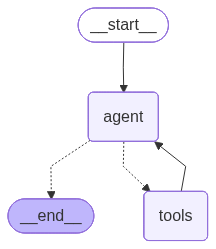

In [26]:
# Define the graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("agent", llm_node)
workflow.add_node("tools", tools_node)

# Set the entry point
workflow.set_entry_point("agent")

# Add edges
# If the agent decides to use a tool, go to the 'tool' node
# Otherwise (if it's a final answer), end the graph
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    "tools"
)

# After a tool is executed, return to the 'agent' node for further reasoning
workflow.add_edge("tools", "agent")
workflow.add_edge("agent", END)

# Compile the graph
app = workflow.compile()
app

In [27]:
query_1 = "Give me the details of student with student id 45642"

result=app.invoke(
    {"messages":
     [{"role": "user",
      "content": query_1}
      ]
     }
    )
print(result["messages"][-1].content)

 LLM NODE EXECUTING
 LLM NODE EXECUTING
 LLM NODE EXECUTING
 LLM NODE EXECUTING
Here are the details for student with ID **45642**:

- **Module Code**: AAA  
- **Presentation Code**: 2013J  
- **Gender**: Female (F)  
- **Region**: North Western Region  
- **Highest Education**: A Level or Equivalent  
- **IMD Band**: 90-100%  
- **Age Band**: 0-35  
- **Previous Attempts**: 0  
- **Credits Studied**: 120  
- **Disability**: None (N)  
- **Final Result**: Pass  

Let me know if you need further analysis!


**TEST CASES**

In [ ]:
test_case = [

    # =========================
    #  SQL / OULAD TEST CASES
    # =========================

    "Give me details of student with student id 45642",

    "Show all information about student 78910",

    "What is the average score of student 45642 across all assessments?",


    # =========================
    #  RAG / STUDENT HANDBOOK
    # =========================

    "What is the minimum attendance requirement for students?",

    "What happens if a student has low attendance?",

    "What are the rules for final examinations?",


    # =========================
    #  PYTHON ANALYTICS TOOL
    # =========================

    "Calculate the average score of students in module AAA",

    "Compute percentage improvement between two assessments",

    "Calculate a risk score for a student with low attendance and low marks",


    # =========================
    #  MULTI-TOOL / COMPLEX REASONING
    # =========================

    "Find students with low scores and calculate their risk level",

    "What happens if a student with low attendance also fails assessments?",

    "Identify at-risk students and explain university policy for supporting them" 
]

# =========================
# RUN ALL TEST CASES
# =========================

for i, question in enumerate(test_case, start=1):

    print("\n" + "=" * 80)
    print(f"TEST CASE {i}: {question}")
    print("=" * 80)

    result = app.invoke({
        "messages": [
            {"role": "user", "content": question}
        ]
    })

    print(result["messages"][-1].content)


TEST CASE 1: Give me details of student with student id 45642
 LLM NODE EXECUTING
